<a href="https://colab.research.google.com/github/ANSH76564/Big_Data/blob/main/mltraniee_task_1_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***EDA(EXPLORATORY DATA ANALYSIS)***
EDA stands for Exploratory Data Analysis. It is the process of examining, cleaning, summarizing, and visualizing data to discover patterns, relationships, trends, and anomalies before applying machine learning or statistical models.


Why did you perform EDA on this Spotify dataset?
To understand:

1.Dataset structure
2.Missing values
3.Duplicate records
4.Distribution of popularity
5.Audio features
6.Genre patterns
7.Relationships between features
8.Factors that may be associated with song popularity





For popularity-related analysis, popularity can be considered the target variable because we are studying how other features relate to song popularity.

However, since this is an EDA project and not a prediction model, we don't technically have to define a target variable.

# ***Exploratory Data Analysis (EDA) on Spotify Dataset***

# ***Objectives***
**Data Cleaning & Deduplication**: Clean missing values and remove duplicate track entries across genres.  

**Statistical Profiling:** Evaluate the central tendencies and distributions of key audio attributes.  

**Correlation Analysis:** Identify relationships between features like energy, loudness, valence, and acousticness.

**Pattern Discovery:** Isolate the distinct musical characteristics of top-charting tracks.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Visual style setup
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Load dataset
df = pd.read_csv("dataset.csv")

*This notebook performs a detailed Exploratory Data Analysis (EDA) on a Spotify music dataset containing 89,740 unique tracks across 113 distinct genres. The primary goal is to analyze audio characteristics, track popularity, genre distributions, artist trends, and explicit content patterns to uncover what key attributes define popular music on streaming .*

1. DATA CLEANING

In [ ]:
df_clean = df.dropna()
df.dropna(inplace=True)

df=pd.read_csv("dataset.csv")
df.shape


(114000, 21)

In [ ]:
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

df_clean = df.dropna()
df.dropna(inplace=True)

print("Missing values count:")
print(df.isnull().sum())


df = df.dropna()
df = df.drop_duplicates(subset=["track_id"])


df["duration_min"] = df["duration_ms"] / 60000

print(f"Dataset shape after cleaning: {df.shape}")

Missing values count:
track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64
Dataset shape after cleaning: (89740, 21)


Duplicate Track IDs

In [ ]:
print("Unique Track IDs:", df["track_id"].nunique())
print("Total Rows:", len(df))

print(
    "Repeated Track ID Rows:",
    df["track_id"].duplicated().sum()
)

duplicate_tracks = df[
    df["track_id"].duplicated(keep=False)
]

display(duplicate_tracks.head(20))


df.drop_duplicates()

Unique Track IDs: 89741
Total Rows: 114000
Repeated Track ID Rows: 24259


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,...,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic,3.844433
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,...,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic,2.493500
5,01MVOl9KtVTNfFiBU9I7dc,Tyrone Wells,Days I Will Remember,Days I Will Remember,58,214240,False,0.688,0.4810,6,...,1,0.1050,0.2890,0.000000,0.1890,0.6660,98.017,4,acoustic,3.570667
6,6Vc5wAMmXdKIAM7WUoEb7N,A Great Big World;Christina Aguilera,Is There Anybody Out There?,Say Something,74,229400,False,0.407,0.1470,2,...,1,0.0355,0.8570,0.000003,0.0913,0.0765,141.284,3,acoustic,3.823333
7,1EzrEOXmMH3G43AXT1y7pA,Jason Mraz,We Sing. We Dance. We Steal Things.,I'm Yours,80,242946,False,0.703,0.4440,11,...,1,0.0417,0.5590,0.000000,0.0973,0.7120,150.960,4,acoustic,4.049100
9,7k9GuJYLp2AzqokyEdwEw2,Ross Copperman,Hunger,Hunger,56,205594,False,0.442,0.6320,1,...,1,0.0295,0.4260,0.004190,0.0735,0.1960,78.899,4,acoustic,3.426567
12,4ptDJbJl35d7gQfeNteBwp,Dan Berk,Solo,Solo,52,198712,False,0.489,0.3140,7,...,0,0.0331,0.7490,0.000000,0.1130,0.6070,124.234,4,acoustic,3.311867
13,0X9MxHR1rTkEHDjp95F2OO,Anna Hamilton,Bad Liar,Bad Liar,62,248448,False,0.691,0.2340,3,...,1,0.0285,0.7770,0.000000,0.1200,0.2090,87.103,4,acoustic,4.140800
16,6xKeQgzfjixSUld14qUezm,Andrew Foy;Renee Foy,ily (i love you baby),ily (i love you baby),56,129750,False,0.706,0.1120,2,...,1,0.0391,0.8270,0.000004,0.1250,0.4140,110.154,4,acoustic,2.162500
17,4Yo0igmcoNyat1secaH0OD,Andrew Foy;Renee Foy,At My Worst,At My Worst,54,169728,False,0.795,0.0841,10,...,0,0.0461,0.7420,0.000012,0.0853,0.6090,91.803,4,acoustic,2.828800


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,...,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic,3.844433
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,...,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic,2.493500
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,...,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic,3.513767
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,...,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic,3.365550
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,...,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic,3.314217
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,...,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music,6.416650
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,...,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music,6.416667
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,...,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music,4.524433
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,...,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music,4.731550


OBSERVATION 1: Data Cleaning
The initial dataset contained 114,000 rows. Missing entries in metadata columns (artists, album_name, track_name) were dropped. Additionally, 24,259 tracks appearing under multiple genres were deduplicated using unique track_id values. Track duration was converted from milliseconds to minutes (duration_min) to improve readability

DATA OVERVIEW

In [ ]:
df = pd.read_csv("dataset.csv")

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print("DATASET SHAPE")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

print("")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")

print("DUPLICATE CHECKS")
print(f"Exact Duplicate Rows: {df.duplicated().sum()}")
print(f"Duplicate Track IDs: {df.duplicated(subset=['track_id']).sum()}")

df_clean = df.dropna().drop_duplicates(subset=["track_id"])

DATASET SHAPE
Rows: 114000, Columns: 20


artists       1
album_name    1
track_name    1
dtype: int64
DUPLICATE CHECKS
Exact Duplicate Rows: 450
Duplicate Track IDs: 24259


Row Having Missing Values

In [ ]:
missing_rows = df[df.isnull().any(axis=1)]

display(missing_rows)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,7,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
df.values

array([['5SuOikwiRyPMVoIQDJUgSV', 'Gen Hoshino', 'Comedy', ..., 87.917,
        4, 'acoustic'],
       ['4qPNDBW1i3p13qLCt0Ki3A', 'Ben Woodward', 'Ghost (Acoustic)',
        ..., 77.489, 4, 'acoustic'],
       ['1iJBSr7s7jYXzM8EGcbK5b', 'Ingrid Michaelson;ZAYN',
        'To Begin Again', ..., 76.332, 4, 'acoustic'],
       ...,
       ['6x8ZfSoqDjuNa5SVP5QjvX', 'Cesária Evora', 'Best Of', ...,
        132.378, 4, 'world-music'],
       ['2e6sXL2bYv4bSz6VTdnfLs', 'Michael W. Smith',
        'Change Your World', ..., 135.96, 4, 'world-music'],
       ['2hETkH7cOfqmz3LqZDHZf5', 'Cesária Evora', 'Miss Perfumado', ...,
        79.198, 4, 'world-music']], dtype=object)

In [ ]:
df.head(20)

In [ ]:
df.tail(20)

In [ ]:
# isnull
df.isnull().sum()

,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0
key,0


In [ ]:
df.columns

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='object')

Numerical and Categorical Columns

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

categorical_cols = df.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical Columns:")
print(numeric_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
['popularity', 'duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'duration_min']

Categorical Columns:
['track_id', 'artists', 'album_name', 'track_name', 'explicit', 'track_genre']


Unique Values

In [ ]:
for col in categorical_cols:
    print("\n--------------------")
    print(col)
    print("Unique Values:", df[col].nunique())


--------------------
track_id
Unique Values: 89741

--------------------
artists
Unique Values: 31437

--------------------
album_name
Unique Values: 46589

--------------------
track_name
Unique Values: 73608

--------------------
explicit
Unique Values: 2

--------------------
track_genre
Unique Values: 114


Dataset Information

In [ ]:
df.info()

print("\nData Types:")
display(df.dtypes.to_frame("Data Type"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           11

,Data Type
track_id,object
artists,object
album_name,object
track_name,object
popularity,int64
duration_ms,int64
explicit,bool
danceability,float64
energy,float64
key,int64


Here is what each Spotify dataset column name means:
**Basic Track Info**




*   track_id: The unique code Spotify gives to each son.
*   track_id: The unique code Spotify gives to each song

*  lbum_name: The name of the album or single where the song appears.

* track_name: The title of the song.

*  track_genre: The musical category or style of the song (like pop, rock, or jazz).




**Numbers and Scores**



*   popularity: A score from 0 to 100 showing how popular the song is right now. Higher numbers mean more plays.
*   duration_ms: How long the song lasts, measured in milliseconds (1 second = 1,000 milliseconds).

*   explicit: Shows if the song has bad words or mature themes (True for yes, False for no).


**Audio Features (Valued 0.0 to 1.0 mostly)**


*   danceability: How good the song is for dancing based on tempo and rhythm. Closer to 1.0 means very easy to dance to.
*   energy: How fast, loud, and noisy the song feels. High energy feels fast.

*   valence: How happy or positive the song sounds. High valence sounds happy and cheerful; low valence sounds sad or angry.
*  tempo: The speed or pace of the song, measured in Beats Per Minute


*  instrument: Tells if the song has no vocals. Closer to 1.0 means the song has only music and no singing
*   acousticness: How acoustic (non-electronic) the song is. A score of 1.0 means it is purely acoustic instruments.
















In [ ]:
df[['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre']]

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


MOST POPULAR SONG

In [ ]:
most_popular = (
    df[
        ["track_name", "artists", "popularity"]
    ]
    .sort_values(
        by="popularity",
        ascending=False
    )
    .head(20)
)

display(most_popular)


,track_name,artists,popularity
81051,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,100
20001,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,100
51664,"Quevedo: Bzrp Music Sessions, Vol. 52",Bizarrap;Quevedo,99
89411,La Bachata,Manuel Turizo,98
30003,I'm Good (Blue),David Guetta;Bebe Rexha,98
20008,I'm Good (Blue),David Guetta;Bebe Rexha,98
81210,I'm Good (Blue),David Guetta;Bebe Rexha,98
88410,La Bachata,Manuel Turizo,98
67356,La Bachata,Manuel Turizo,98
68303,La Bachata,Manuel Turizo,98


Top Genres

,count
track_genre,
acoustic,1000
afrobeat,1000
alt-rock,1000
alternative,1000
ambient,1000
anime,1000
black-metal,1000
bluegrass,1000
blues,1000


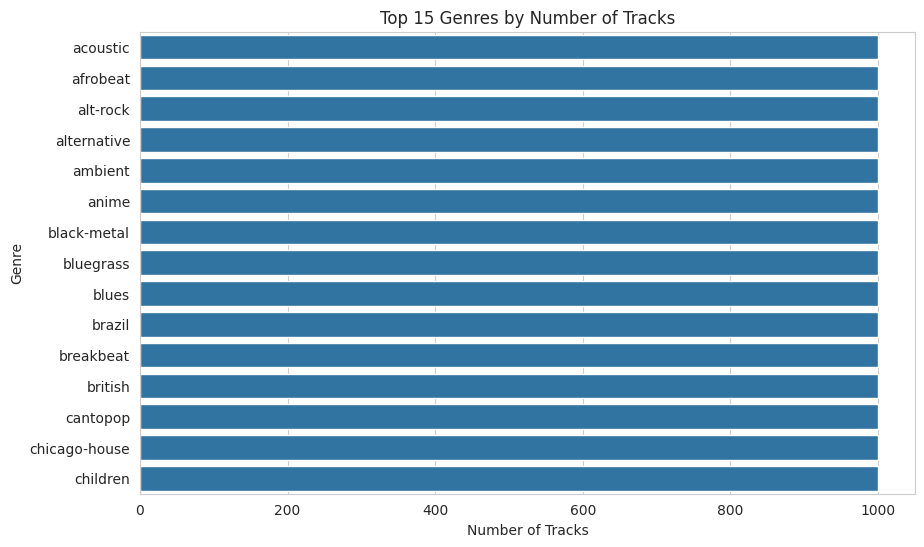

In [ ]:
top_genres = df["track_genre"].value_counts().head(15)

display(top_genres)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 15 Genres by Number of Tracks")
plt.xlabel("Number of Tracks")
plt.ylabel("Genre")

plt.show()

Top Artists by Number of Songs

,count
artists,
The Beatles,279
George Jones,271
Stevie Wonder,236
Linkin Park,224
Ella Fitzgerald,222
Prateek Kuhad,217
Feid,202
Chuck Berry,190
Håkan Hellström,183


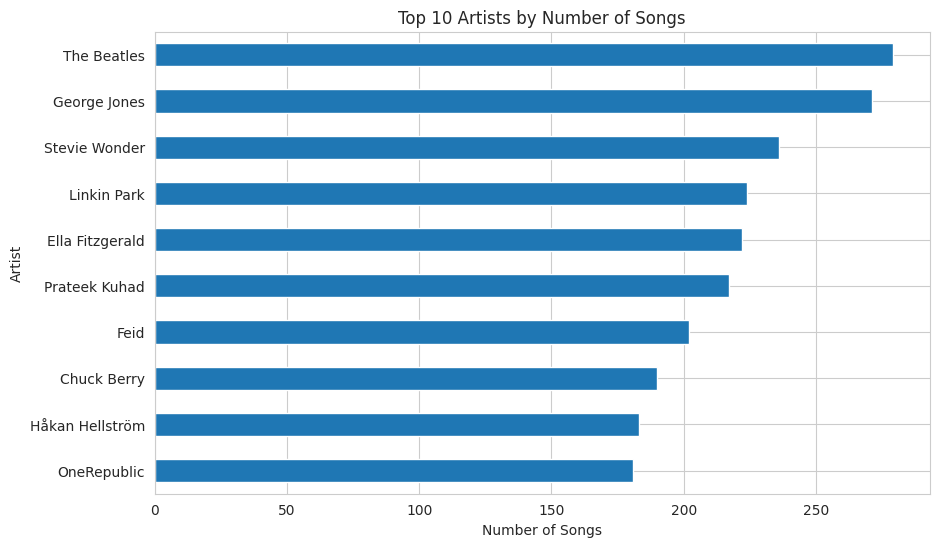

In [ ]:
top_artists = (
    df["artists"]
    .value_counts()
    .head(10)
)

display(top_artists)

plt.figure(figsize=(10, 6))

top_artists.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Artists by Number of Songs")
plt.xlabel("Number of Songs")
plt.ylabel("Artist")

plt.show()

Popularity Categories

,count
popularity_category,
Low,42821
Medium,41812
High,26536
Very High,2831


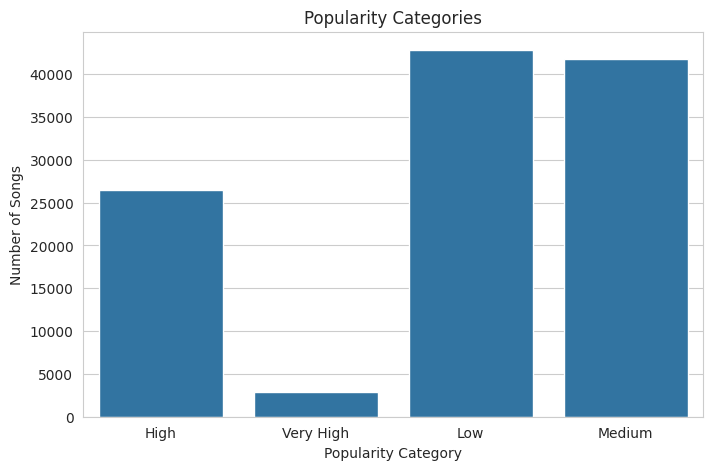

In [ ]:
def popularity_category(x):

    if x < 25:
        return "Low"

    elif x < 50:
        return "Medium"

    elif x < 75:
        return "High"

    else:
        return "Very High"


df["popularity_category"] = (
    df["popularity"]
    .apply(popularity_category)
)

display(
    df["popularity_category"]
    .value_counts()
)

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="popularity_category"
)

plt.title("Popularity Categories")
plt.xlabel("Popularity Category")
plt.ylabel("Number of Songs")

plt.show()

3. DESCRIPTIVE STATISTICS

In [ ]:
num_cols = [
    "popularity",
    "duration_min",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
]

df["duration_min"] = df["duration_ms"] / 60000

print("Summary Statistics:")
df[num_cols].describe().T

Summary Statistics:


,count,mean,std,min,25%,50%,75%,max
popularity,114000.0,33.238535,22.305078,0.000,17.00000,35.000000,50.000000,100.00000
duration_min,114000.0,3.800486,1.788295,0.000,2.90110,3.548433,4.358433,87.28825
danceability,114000.0,0.566800,0.173542,0.000,0.45600,0.580000,0.695000,0.98500
energy,114000.0,0.641383,0.251529,0.000,0.47200,0.685000,0.854000,1.00000
loudness,114000.0,-8.258960,5.029337,-49.531,-10.01300,-7.004000,-5.003000,4.53200
speechiness,114000.0,0.084652,0.105732,0.000,0.03590,0.048900,0.084500,0.96500
acousticness,114000.0,0.314910,0.332523,0.000,0.01690,0.169000,0.598000,0.99600
instrumentalness,114000.0,0.156050,0.309555,0.000,0.00000,0.000042,0.049000,1.00000
liveness,114000.0,0.213553,0.190378,0.000,0.09800,0.132000,0.273000,1.00000
valence,114000.0,0.474068,0.259261,0.000,0.26000,0.464000,0.683000,0.99500


In [ ]:
print("The average popularity of songs is:", round(df["popularity"].mean(), 2))
print("The middle popularity score is:", df["popularity"].median())
print("The highest popularity score is:", df["popularity"].max())
print("The lowest popularity score is:", df["popularity"].min())

In [ ]:
df.groupby('artists')['popularity'].sum().sort_values(ascending=False)

In [ ]:
df.groupby('artists')['track_name'].sum().sort_values(ascending=False)

For categorical variables:

In [ ]:
display(df.describe(include="object").T)

,count,unique,top,freq
track_id,114000,89741,6S3JlDAGk3uu3NtZbPnuhS,9
artists,113999,31437,The Beatles,279
album_name,113999,46589,Alternative Christmas 2022,195
track_name,113999,73608,Run Rudolph Run,151
track_genre,114000,114,acoustic,1000


# **observation 3**
The dataset exhibits a broad range of song metrics. The mean popularity score is 32.85 out of 100. Songs average 3.80 minutes in length, with strong overall energy levels (mean: 0.63) and moderate danceability (mean: 0.56). Most tracks are non-instrumental with low acousticness scores.  

Distribution of Popularity

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["popularity"],
    bins=20,
    kde=True
)

plt.title("Distribution of Song Popularity")
plt.xlabel("Popularity")
plt.ylabel("Number of Songs")
plt.show()


print("Mean Popularity:",
      round(df["popularity"].mean(), 2))

print("Median Popularity:",
      df["popularity"].median())

print("Maximum Popularity:",
      df["popularity"].max())

print("Minimum Popularity:",
      df["popularity"].min())

UNIVARIATE ANALYSIS (DISTRIBUTIONS)

/tmp/ipykernel_2277/1075675088.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_all.index, y=mean_all.values, palette='magma')


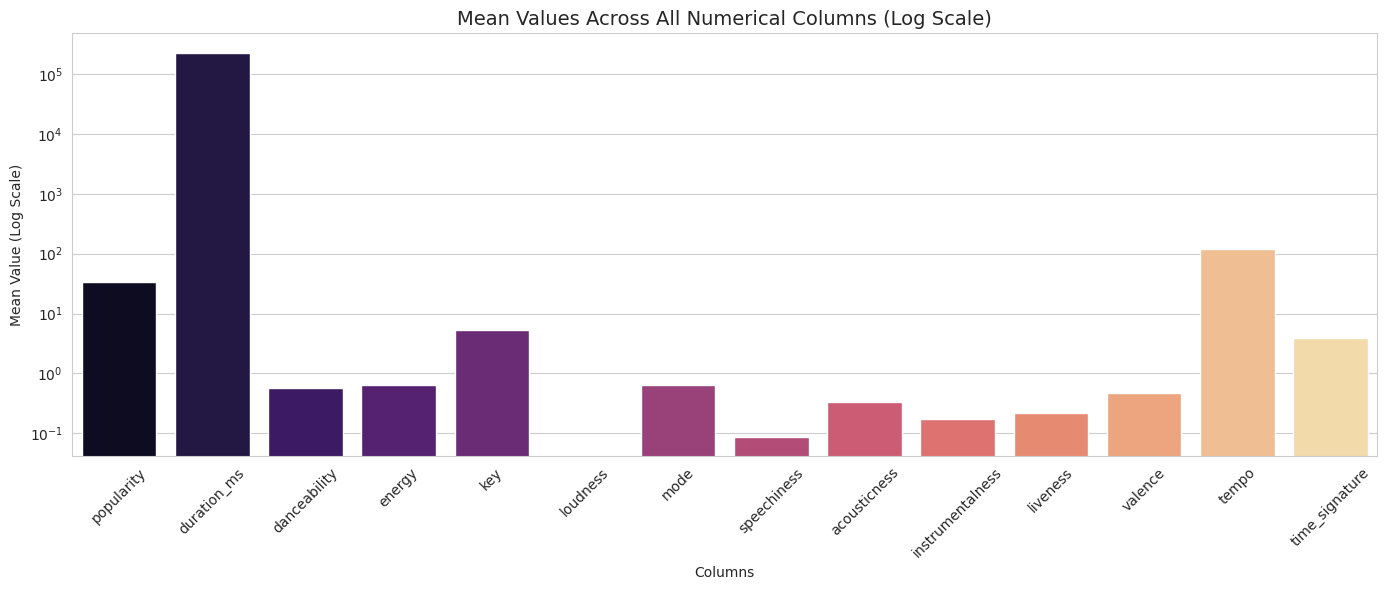

In [ ]:
num_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns
mean_all = df_clean[num_cols].mean()

plt.figure(figsize=(14, 6))
sns.barplot(x=mean_all.index, y=mean_all.values, palette='magma')
plt.title('Mean Values Across All Numerical Columns (Log Scale)', fontsize=14)
plt.ylabel('Mean Value (Log Scale)')
plt.yscale('log')
plt.xlabel('Columns')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

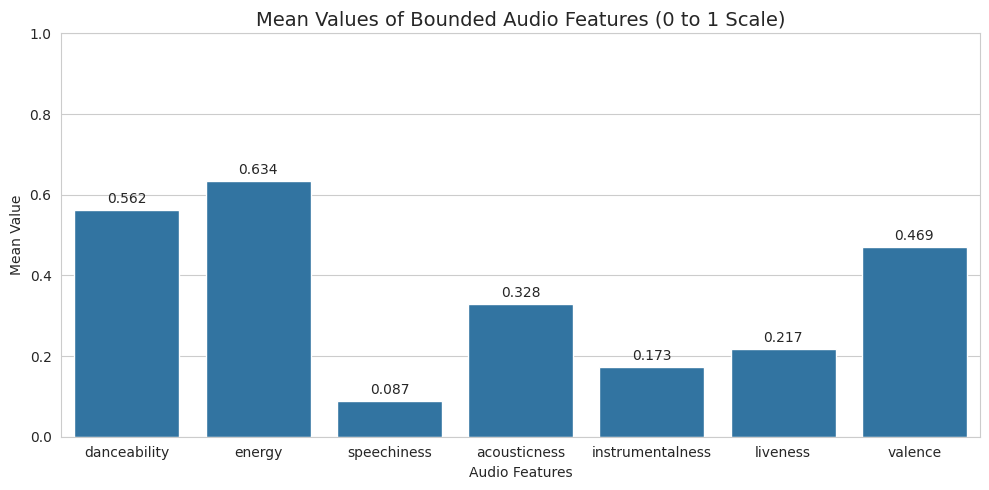

In [ ]:
bounded_features = [
    'danceability',
    'energy',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
]
mean_values = df_clean[bounded_features].mean()

plt.figure(figsize=(10, 5))
bars = sns.barplot(
    x=mean_values.index, y=mean_values.values
)
plt.title('Mean Values of Bounded Audio Features (0 to 1 Scale)', fontsize=14)
plt.ylabel('Mean Value')
plt.xlabel('Audio Features')
plt.ylim(0, 1)

for bar in bars.patches:
  bars.annotate(
      f'{bar.get_height():.3f}',
      (bar.get_x() + bar.get_width() / 2.0, bar.get_height()),
      ha='center',
      va='bottom',
      fontsize=10,
      xytext=(0, 3),
      textcoords='offset points',
  )

plt.tight_layout()
plt.show()

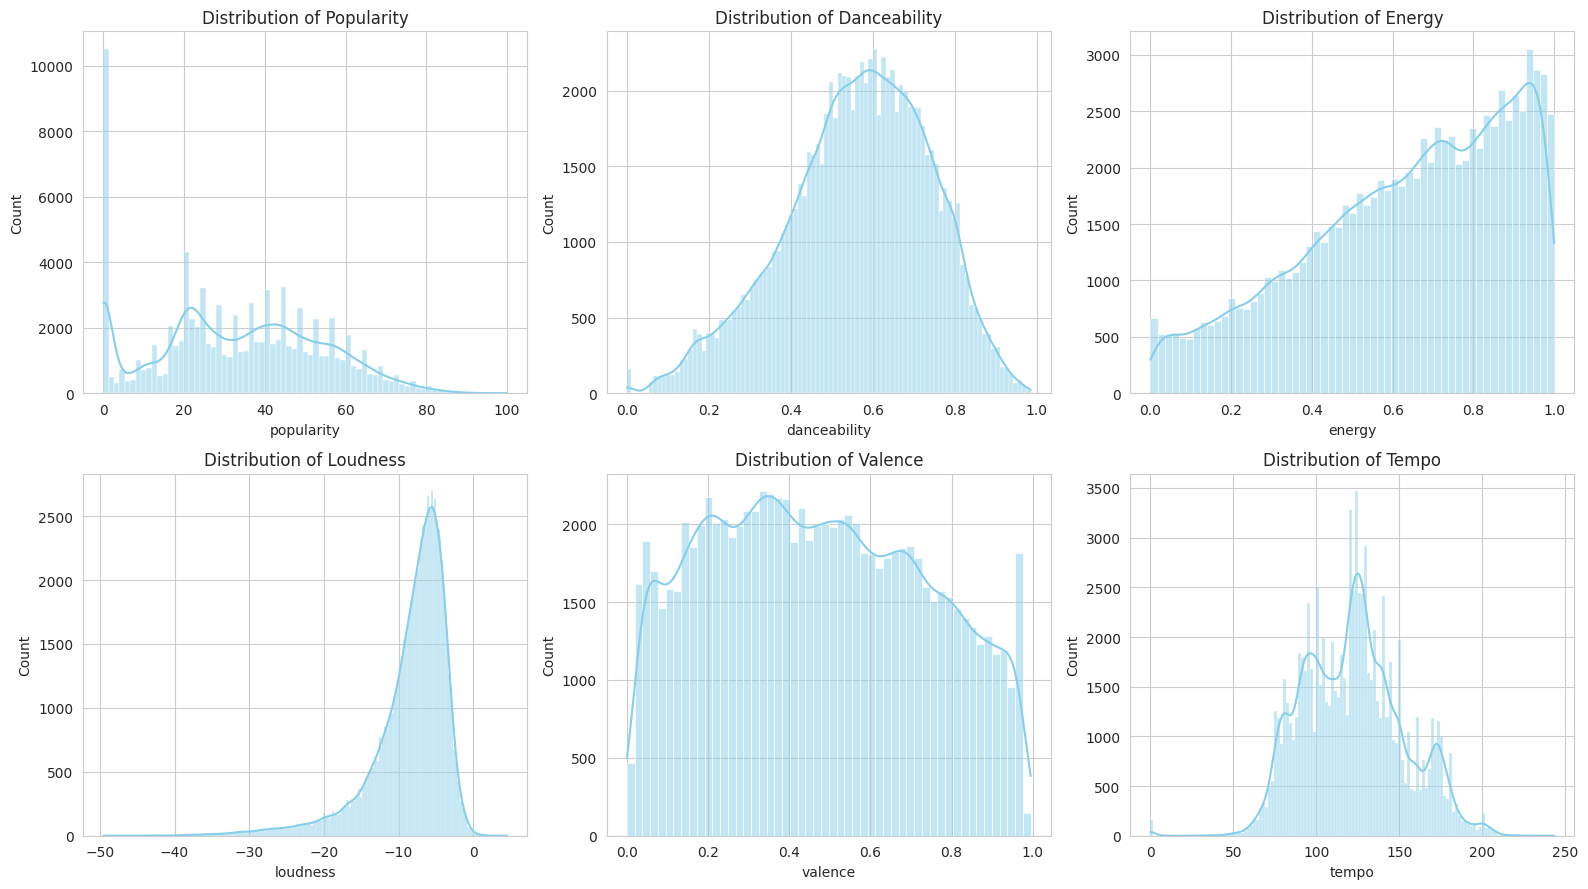

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
features_to_plot = [
    "popularity",
    "danceability",
    "energy",
    "loudness",
    "valence",
    "tempo",
]

for idx, col in enumerate(features_to_plot):
    ax = axes[idx // 3, idx % 3]
    sns.histplot(df_clean[col], kde=True, ax=ax, color="skyblue")
    ax.set_title(f"Distribution of {col.capitalize()}")

plt.tight_layout()
plt.show()

ARTIST ANALYSIS

/tmp/ipykernel_2277/2021289753.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_artists.values, y=top_artists.index, palette="mako")


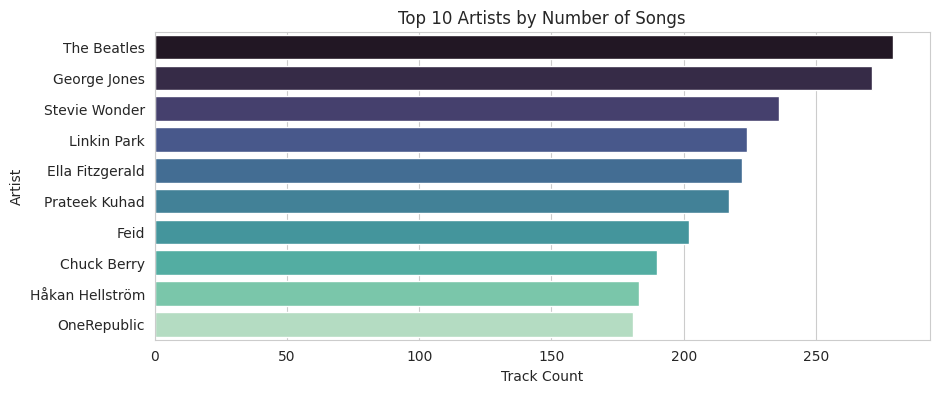

In [ ]:
top_artists = df["artists"].value_counts().head(10)

plt.figure(figsize=(10, 4))
sns.barplot(x=top_artists.values, y=top_artists.index, palette="mako")
plt.title("Top 10 Artists by Number of Songs")
plt.xlabel("Track Count")
plt.ylabel("Artist")
plt.show()

GENERS

/tmp/ipykernel_2277/3722444047.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_2277/3722444047.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


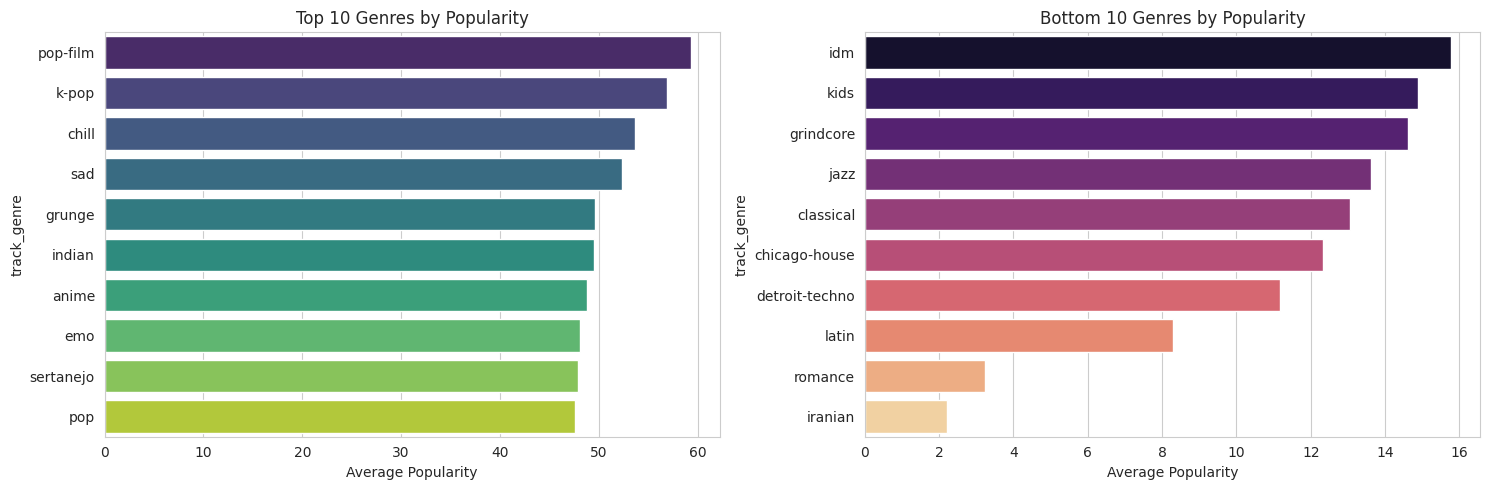

In [ ]:
genre_pop = (
    df.groupby("track_genre")["popularity"]
    .mean()
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))


sns.barplot(
    x=genre_pop.head(10).values,
    y=genre_pop.head(10).index,
    ax=axes[0],
    palette="viridis",
)
axes[0].set_title("Top 10 Genres by Popularity")
axes[0].set_xlabel("Average Popularity")

sns.barplot(
    x=genre_pop.tail(10).values,
    y=genre_pop.tail(10).index,
    ax=axes[1],
    palette="magma",
)
axes[1].set_title("Bottom 10 Genres by Popularity")
axes[1].set_xlabel("Average Popularity")

plt.tight_layout()
plt.show()

POPULARITY ANALYSIS

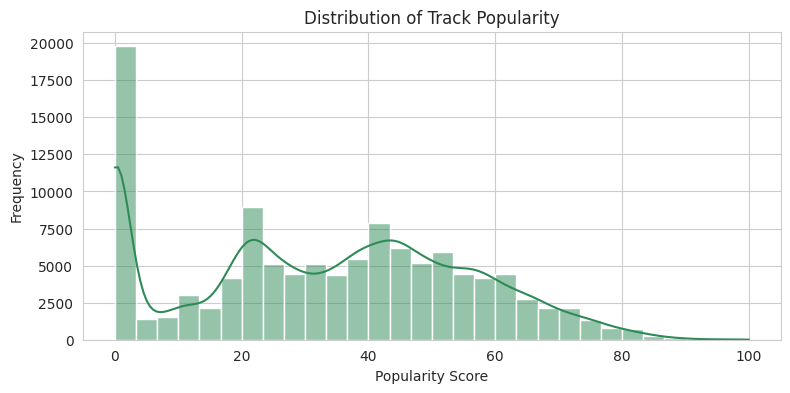

Top 10 Most Popular Tracks:


,track_name,artists,popularity,track_genre
81051,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,100,pop
20001,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,100,dance
51664,"Quevedo: Bzrp Music Sessions, Vol. 52",Bizarrap;Quevedo,99,hip-hop
89411,La Bachata,Manuel Turizo,98,reggaeton
30003,I'm Good (Blue),David Guetta;Bebe Rexha,98,edm
20008,I'm Good (Blue),David Guetta;Bebe Rexha,98,dance
81210,I'm Good (Blue),David Guetta;Bebe Rexha,98,pop
88410,La Bachata,Manuel Turizo,98,reggae
67356,La Bachata,Manuel Turizo,98,latin
68303,La Bachata,Manuel Turizo,98,latino


In [ ]:
plt.figure(figsize=(9, 4))
sns.histplot(df["popularity"], bins=30, kde=True, color="seagreen")
plt.title("Distribution of Track Popularity")
plt.xlabel("Popularity Score")
plt.ylabel("Frequency")
plt.show()

# Display top 10 most popular songs
top_songs = df.sort_values(by="popularity", ascending=False)[
    ["track_name", "artists", "popularity", "track_genre"]
].head(10)

print("Top 10 Most Popular Tracks:")
top_songs

AUDIO ANALYSIS

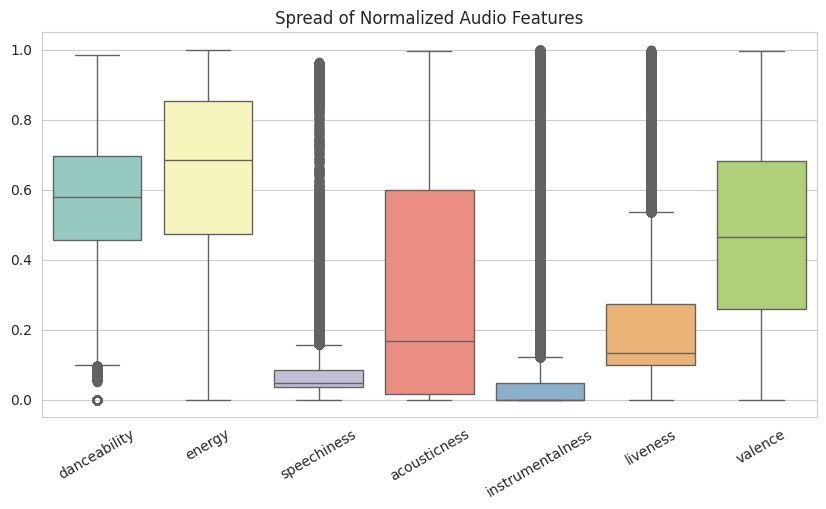

In [ ]:
audio_cols = [
    "danceability",
    "energy",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
]

plt.figure(figsize=(10, 5))
sns.boxplot(data=df[audio_cols], palette="Set3")
plt.title("Spread of Normalized Audio Features")
plt.xticks(rotation=30)
plt.show()

Distribution of Audio Features

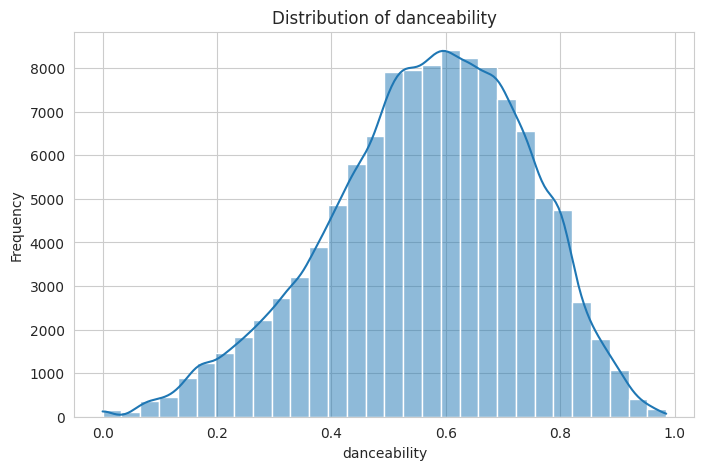

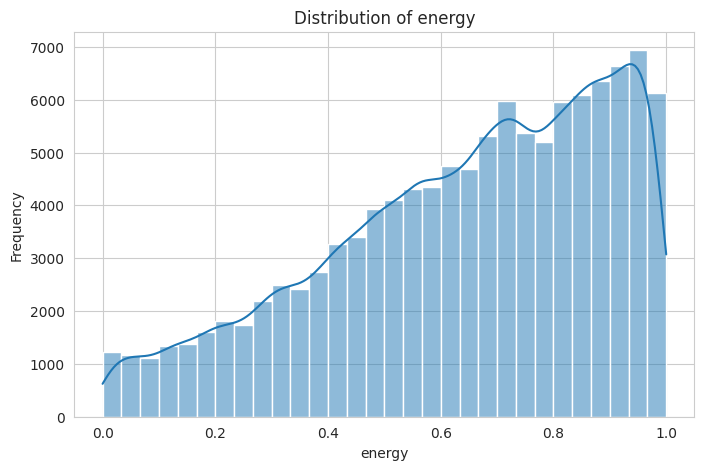

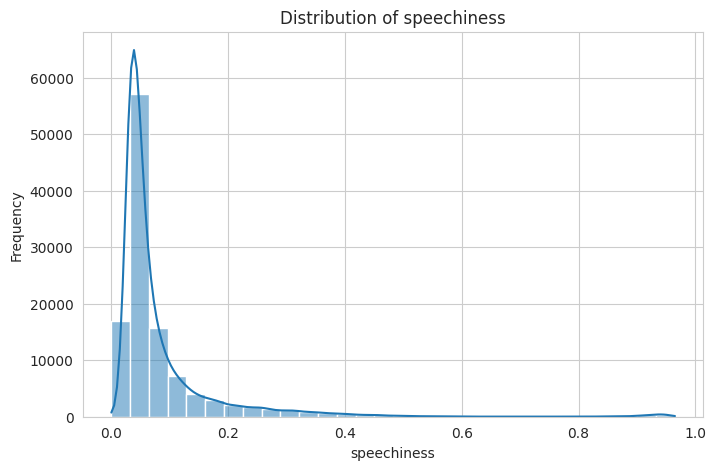

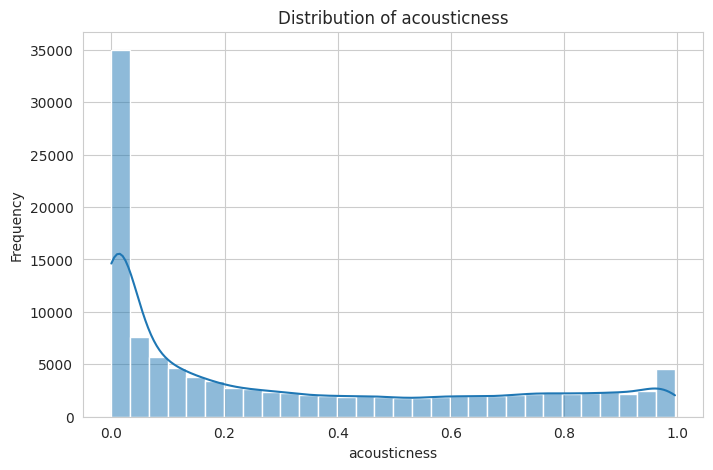

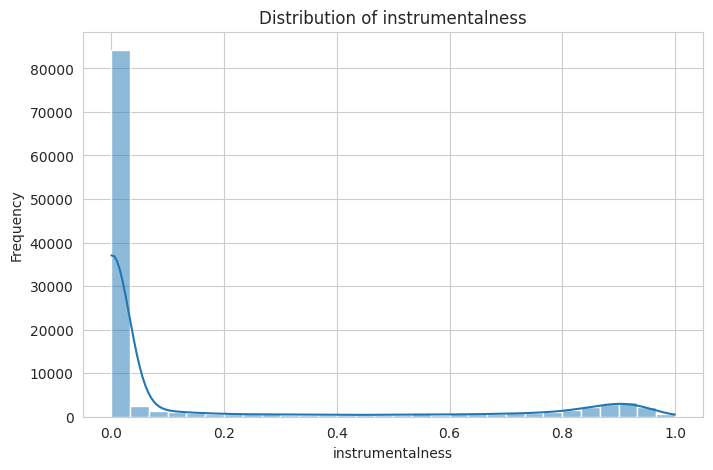

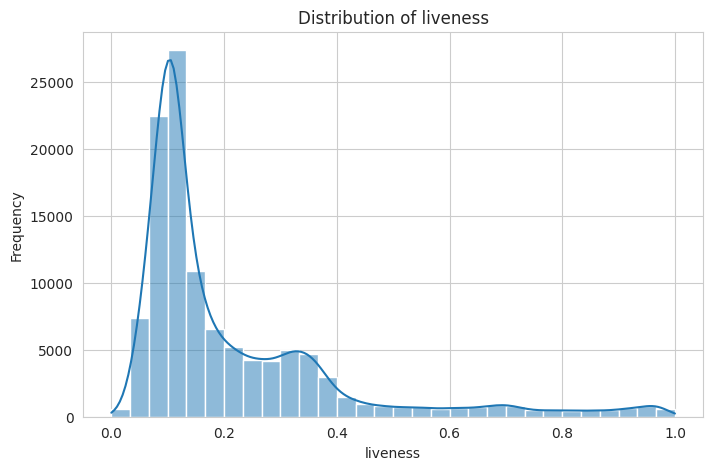

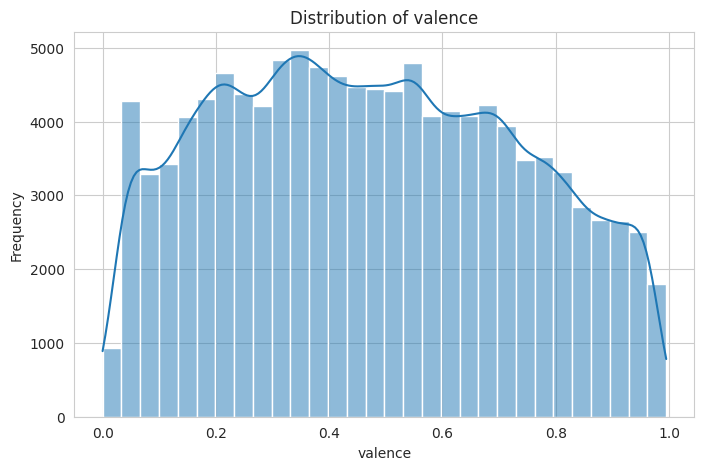

In [ ]:
audio_features = [
    "danceability",
    "energy",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence"
]

for col in audio_features:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        df[col],
        bins=30,
        kde=True
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

Tempo Distribution

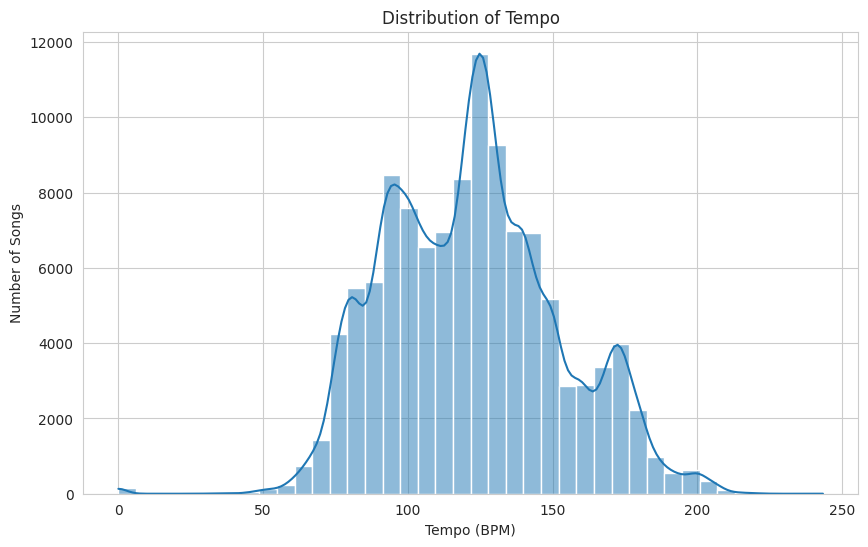

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["tempo"],
    bins=40,
    kde=True
)

plt.title("Distribution of Tempo")
plt.xlabel("Tempo (BPM)")
plt.ylabel("Number of Songs")

plt.show()

DISTRIBUTIVE RELATION

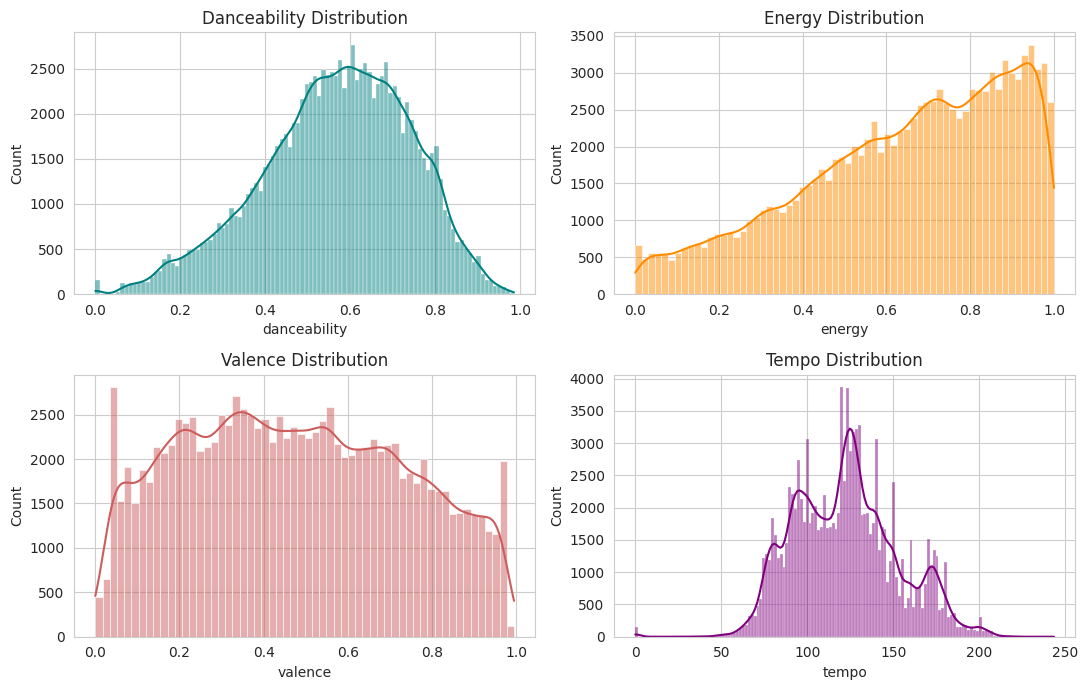

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

sns.histplot(df["danceability"], kde=True, ax=axes[0, 0], color="teal")
axes[0, 0].set_title("Danceability Distribution")

sns.histplot(df["energy"], kde=True, ax=axes[0, 1], color="darkorange")
axes[0, 1].set_title("Energy Distribution")

sns.histplot(df["valence"], kde=True, ax=axes[1, 0], color="indianred")
axes[1, 0].set_title("Valence Distribution")

sns.histplot(df["tempo"], kde=True, ax=axes[1, 1], color="purple")
axes[1, 1].set_title("Tempo Distribution")

plt.tight_layout()
plt.show()

EXPLICIT

/tmp/ipykernel_2277/3443399422.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


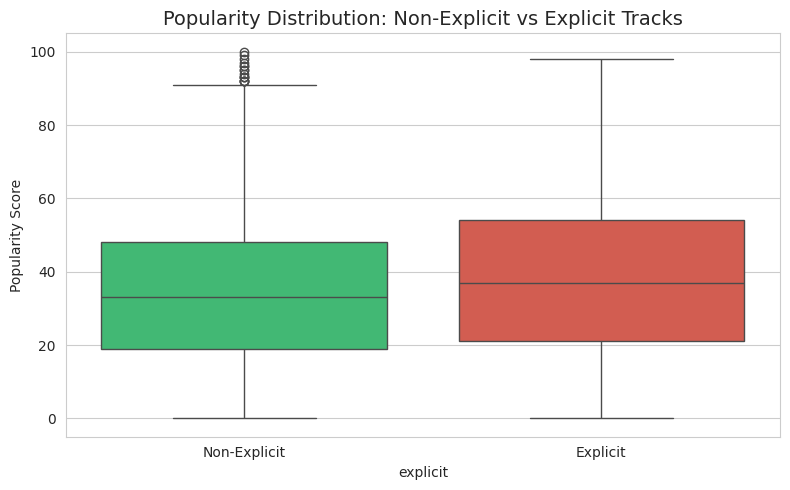

/tmp/ipykernel_2277/3443399422.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


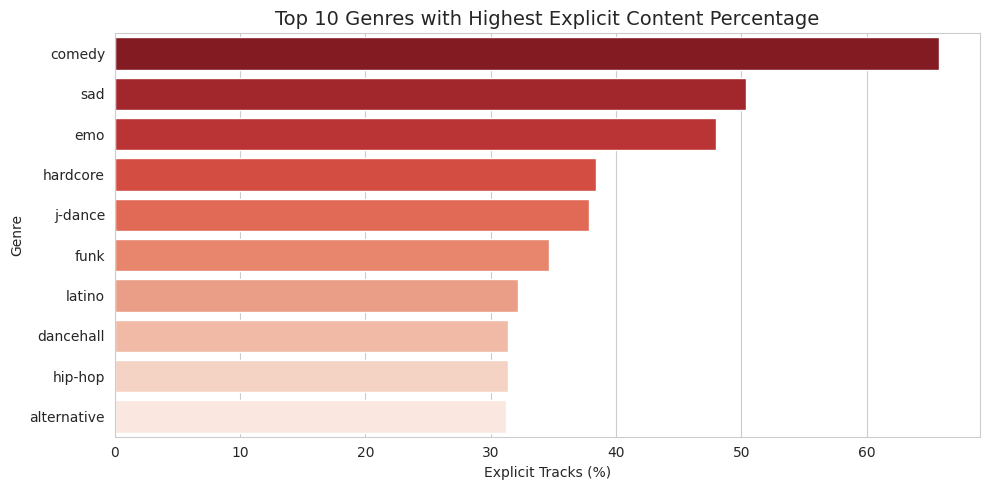

=== Audio Profile Comparison: Explicit vs Non-Explicit ===
          popularity  danceability  energy  speechiness
explicit                                               
False         32.853         0.556   0.627        0.076
True          36.886         0.631   0.719        0.209


In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_clean, x='explicit', y='popularity', palette=['#2ecc71', '#e74c3c']
)
plt.title('Popularity Distribution: Non-Explicit vs Explicit Tracks', fontsize=14)
plt.xticks([0, 1], ['Non-Explicit', 'Explicit'])
plt.ylabel('Popularity Score')
plt.tight_layout()
plt.show()

explicit_genres = (
    df_clean.groupby('track_genre')['explicit'].mean().nlargest(10).reset_index()
)
explicit_genres['explicit_pct'] = explicit_genres['explicit'] * 100

plt.figure(figsize=(10, 5))
sns.barplot(
    data=explicit_genres, x='explicit_pct', y='track_genre', palette='Reds_r'
)
plt.title('Top 10 Genres with Highest Explicit Content Percentage', fontsize=14)
plt.xlabel('Explicit Tracks (%)')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

explicit_profile = (
    df_clean.groupby('explicit')[
        ['popularity', 'danceability', 'energy', 'speechiness']
    ]
    .mean()
    .round(3)
)
print('=== Audio Profile Comparison: Explicit vs Non-Explicit ===')
print(explicit_profile)

Explicit (True / 1 / "Yes"): The song contains strong language or mature themes and is tagged with an "E" label on Spotify.


Non-Explicit (False / 0 / "No"): The song is "clean" and does not contain mature language.

**OBSERVATION**

CORE rhythm indicators display key patterns: tempo centers around standard commercial beats (120 BPM), danceability follows a smooth bell curve, and valence (musical mood) is evenly distributed between melancholic and upbeat tracks

CORRELATION AND RELATION

A relationship means that two variables are connected in some way.

For example, in Spotify:

Energy of a song
Danceability of a song

We can ask:

"When energy increases, does danceability also tend to change?"

If there is some pattern between them, we say there is a relationship.

Correlation is a statistical measurement of the relationship between two numerical variables.

It tells us:

Direction of the relationship
Strength of the relationship

The correlation coefficient is usually represented by r and ranges from:

−1≤r≤+1

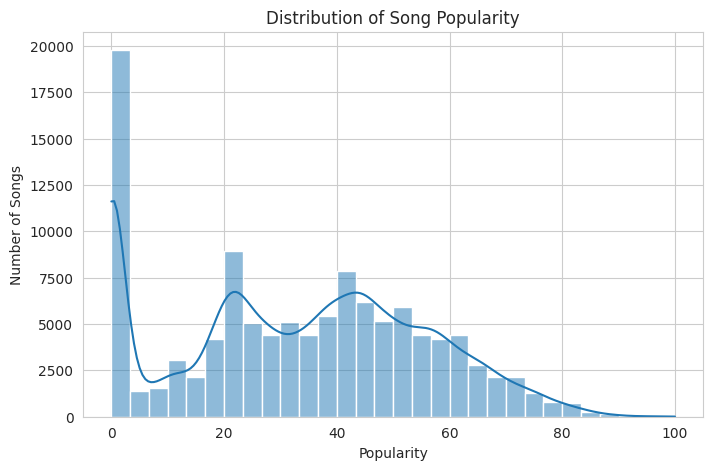

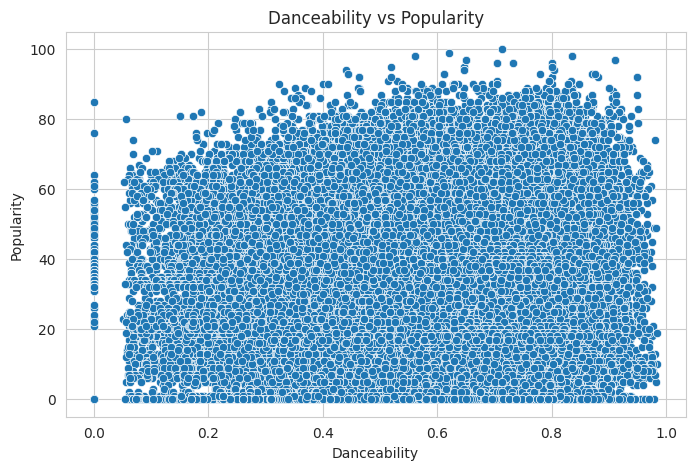

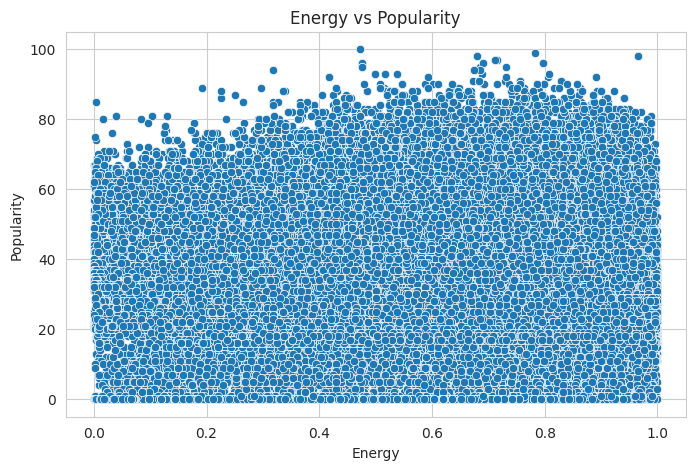

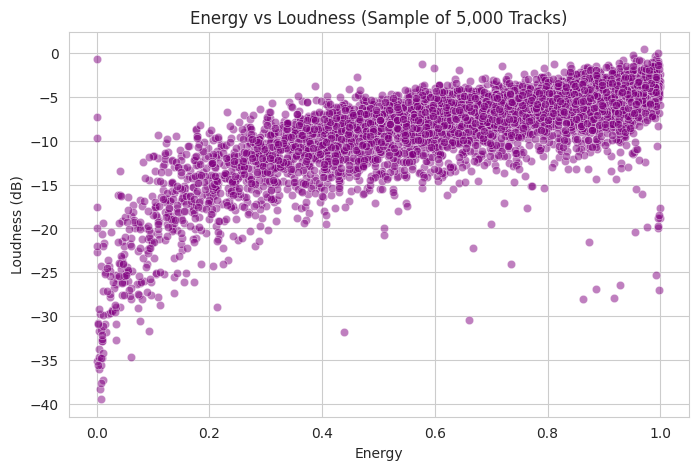

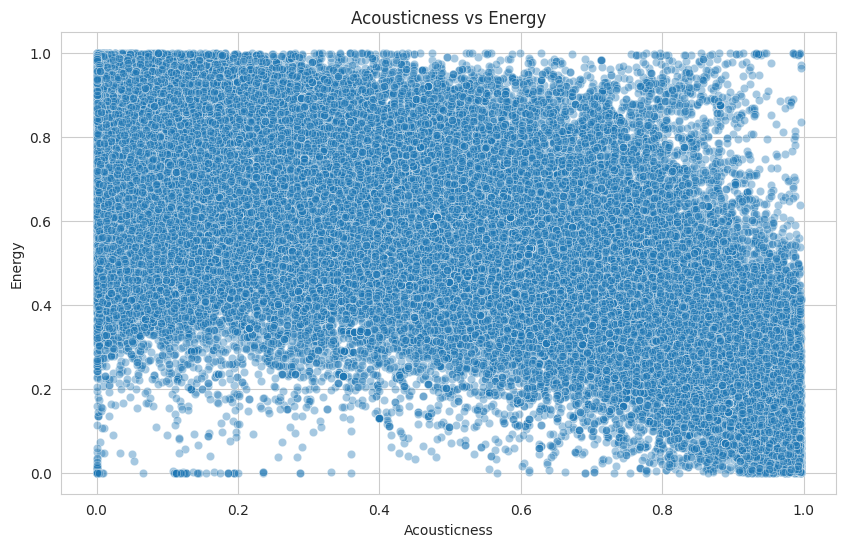

In [ ]:
#RELATION
plt.figure(figsize=(8, 5))
sns.histplot(df['popularity'], bins=30, kde=True)
plt.title('Distribution of Song Popularity')
plt.xlabel('Popularity')
plt.ylabel('Number of Songs')
plt.show()


plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='danceability', y='popularity')
plt.title('Danceability vs Popularity')
plt.xlabel('Danceability')
plt.ylabel('Popularity')
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='energy', y='popularity')
plt.title('Energy vs Popularity')
plt.xlabel('Energy')
plt.ylabel('Popularity')
plt.show()
top_artists = df.groupby('artists')['popularity'].mean().nlargest(10).reset_index()

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_clean.sample(5000, random_state=42),
    x="energy",
    y="loudness",
    alpha=0.5,
    color="purple",
)
plt.title("Energy vs Loudness (Sample of 5,000 Tracks)")
plt.xlabel("Energy")
plt.ylabel("Loudness (dB)")
plt.show()

#Acousticness vs Energy

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="acousticness",
    y="energy",
    alpha=0.4
)

plt.title("Acousticness vs Energy")
plt.xlabel("Acousticness")
plt.ylabel("Energy")

plt.show()




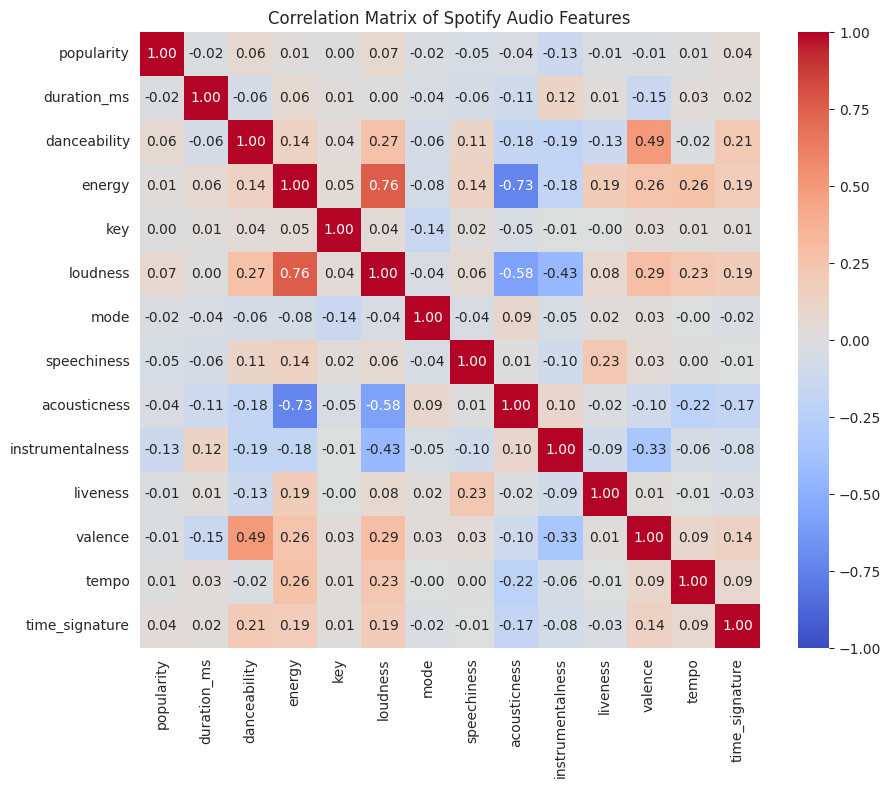

In [ ]:
#Correlation Heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df_clean[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Spotify Audio Features")
plt.show()

Correlation with Popularity

In [ ]:
popularity_corr = (
    numeric_df.corr()["popularity"]
    .sort_values(ascending=False)
)

display(popularity_corr)

,popularity
popularity,1.000000
loudness,0.050423
danceability,0.035448
time_signature,0.031073
tempo,0.013205
energy,0.001056
key,-0.003853
liveness,-0.005387
duration_ms,-0.007101
mode,-0.013931


In [ ]:
loud_energy_corr = df['loudness'].corr(df['energy'])
print(f"Correlation between Loudness & Energy: {loud_energy_corr:.3f}")

OBSEVATION
A strong positive linear relationship exists between energy and loudness ($r = 0.76$). Conversely, energy and acousticness show a strong negative relationship ($r = -0.73$), demonstrating that higher acoustic content corresponds directly to lower production energy

GRAPH BETWEEN THE COLUMNS


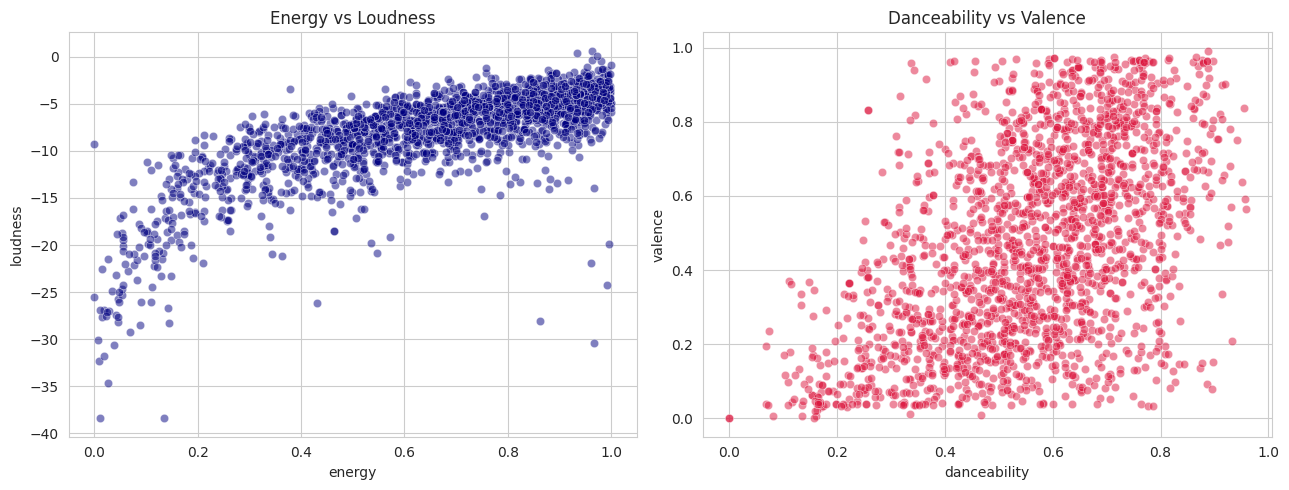

<Figure size 1000x500 with 0 Axes>

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Sample 2,000 rows for cleaner plotting
sample_df = df.sample(2000, random_state=42)
# Energy vs Loudness
sns.scatterplot(
    data=sample_df,
    x="energy",
    y="loudness",
    alpha=0.5,
    ax=axes[0],
    color="navy",
)
axes[0].set_title("Energy vs Loudness")

# 2 Danceability vs Valence
sns.scatterplot(
    data=sample_df,
    x="danceability",
    y="valence",
    alpha=0.5,
    ax=axes[1],
    color="crimson",
)
axes[1].set_title("Danceability vs Valence")

plt.tight_layout()
plt.show()

# 3. Acousticness vs Energy
sns.scatterplot(
    data=sample_df,
    x="acousticness",
    y="energy",
    alpha=0.5,
    ax=axes[1],
    color="forestgreen",
)
axes[1].set_title("Acousticness vs Energy")

# 4. Danceability vs Tempo
sns.scatterplot(
    data=sample_df,
    x="danceability",
    y="tempo",
    alpha=0.5,
    ax=axes[1],
    color="darkorange",
)
axes[1].set_title("Danceability vs Tempo")

# 5. Loudness vs Popularity
sns.scatterplot(
    data=sample_df,
    x="loudness",
    y="popularity",
    alpha=0.5,
    ax=axes[1],
    color="purple",
)
axes[1].set_title("Loudness vs Popularity")

# 6. Valence vs Energy
sns.scatterplot(
    data=sample_df,
    x="valence",
    y="energy",
    alpha=0.5,
    ax=axes[1],
    color="teal",
)
axes[1].set_title("Valence vs Energy")




plt.tight_layout()
plt.show()

CHARACTERISTIC OF HIGHLY POPULAR TRACKS

Total highly popular tracks (>=80): 1201

Mean Audio Feature Comparison:


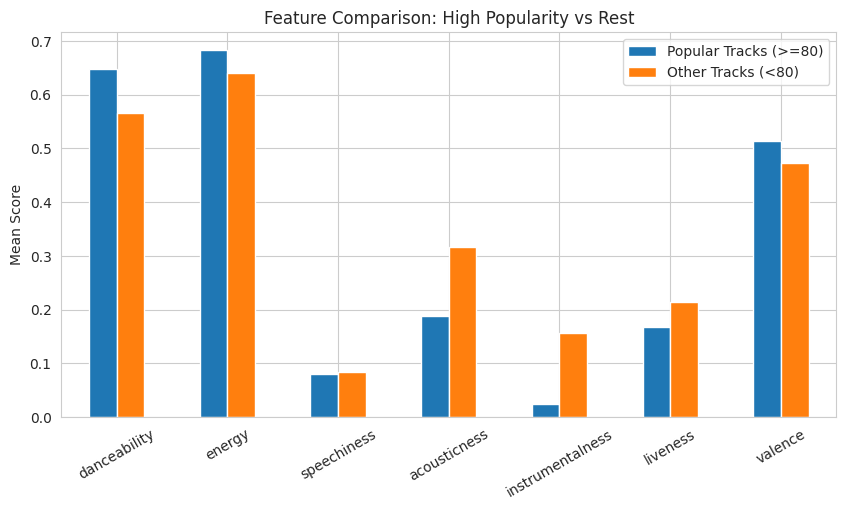

In [ ]:
popular_tracks = df[df["popularity"] >= 80]
other_tracks = df[df["popularity"] < 80]

print(f"Total highly popular tracks (>=80): {len(popular_tracks)}")

feature_comp = pd.DataFrame(
    {
        "Popular Tracks (>=80)": popular_tracks[audio_cols].mean(),
        "Other Tracks (<80)": other_tracks[audio_cols].mean(),
    }
)

print("\nMean Audio Feature Comparison:")
feature_comp

# Visual comparison chart
feature_comp.plot(kind="bar", figsize=(10, 5))
plt.title("Feature Comparison: High Popularity vs Rest")
plt.ylabel("Mean Score")
plt.xticks(rotation=30)
plt.show()

In [ ]:
print("reation with the popularity")
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()['popularity'].sort_values(ascending=False)
print(corr)

In [ ]:
df.groupby('artists')['track_name'].sum().sort_values(ascending=False)

In [ ]:
df.groupby('artists')['acousticness'].sum().sort_values(ascending=False)

In [ ]:
artist_listening_min = (df_clean.groupby('artists')['duration_ms'].sum() / 60000).round(2)
top_listening_artists = artist_listening_min.sort_values(ascending=False)
print(top_listening_artists.head(10))

valid_artists = df_clean['artists'].value_counts()[lambda x: x > 10].index
print(valid_artists)
top_by_time = (df_clean[df_clean['artists'].isin(valid_artists)].groupby('artists')['duration_ms'].sum() / 60000).sort_values(ascending=False)
print(top_by_time)

Characteristic of Highly Popular Tracks
Isolating hit songs (popularity $\ge 80$) reveals clear musical benchmarks:  Higher Danceability: Hits average 0.65 danceability vs. 0.56 for standard tracks.  Louder Mastering: Hits average -6.25 dB vs. -8.51 dB for standard tracks.  Minimal Instrumental Content: Hits average only 0.02 instrumentalness, indicating that vocals are nearly essential for major popularity

**Final Dataset Check**

In [ ]:
print("========== FINAL DATASET CHECK ==========")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print(
    "Missing Values:",
    df.isnull().sum().sum()
)

print(
    "Exact Duplicate Rows:",
    df.duplicated().sum()
)

print(
    "Unique Track IDs:",
    df["track_id"].nunique()
)

print(
    "Unique Artists:",
    df["artists"].nunique()
)

print(
    "Unique Genres:",
    df["track_genre"].nunique()
)

========== FINAL DATASET CHECK ==========
Rows: 114000
Columns: 21
Missing Values: 3
Exact Duplicate Rows: 450
Unique Track IDs: 89741
Unique Artists: 31437
Unique Genres: 114


***Final EDA Summary***

In [ ]:
print("========== EDA SUMMARY ==========")

print("\nDataset:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nData Quality:")
print(
    "Missing Values:",
    df.isnull().sum().sum()
)
print(
    "Duplicate Rows:",
    df.duplicated().sum()
)

print("\nUnique Values:")
print(
    "Unique Tracks:",
    df["track_id"].nunique()
)
print(
    "Unique Artists:",
    df["artists"].nunique()
)
print(
    "Unique Genres:",
    df["track_genre"].nunique()
)

print("\nPopularity:")
print(
    "Mean:",
    round(df["popularity"].mean(), 2)
)
print(
    "Median:",
    df["popularity"].median()
)
print(
    "Maximum:",
    df["popularity"].max()
)

print("\nAudio Features:")
print(
    "Danceability:",
    round(df["danceability"].mean(), 3)
)
print(
    "Energy:",
    round(df["energy"].mean(), 3)
)
print(
    "Valence:",
    round(df["valence"].mean(), 3)
)


The dataset contains 114,000 records and 21 columns.
It contains information about tracks, artists, albums, genres, popularity, and audio characteristics.
There are 114 different genres.
Data Quality:

*   Data Quality:

There are 3 missing values in total.
The missing values occur in artists, album_name, and track_name.
There are 0 exact duplicate rows.
However, there are repeated track_id values, so track ID duplication should not automatically be considered an error.


*   SONG AND ARTISTS:
There are approximately 89,741 unique track IDs.
There are approximately 31,437 unique artist entries.
The dataset contains artists from a wide range of musical categories and genres.

*   POPULARITY:

Average popularity is approximately 33.24.
Median popularity is 35.
The maximum popularity is 100.
Popularity is not evenly distributed across all songs.


*   Audio Features:

Average danceability is approximately 0.567.
Average energy is approximately 0.641.
Average valence is approximately 0.474.
Songs generally show moderate danceability and relatively high energy.


*   Correlations


Most individual audio features have only weak correlations with popularity.
Instrumentalness has the strongest negative relationship with popularity among the major audio features, but the correlation is still weak.
Therefore, popularity cannot be explained effectively by a single audio feature.


*   OUTLIERS


Some variables contain potential outliers.
Extreme values should be investigated rather than automatically deleted because they may represent legitimate musical characteristics.

Applications:

The EDA can be useful for:

*   Music recommendation systems

*   Popularity prediction

*   Artist analysis

*   Playlist generation

*   Genre analysis

*   Music trend analysis









Conducting Exploratory Data Analysis (EDA) on the Spotify dataset yields critical insights into track distribution, music trends, audio feature correlations, and the specific drivers behind popular hits:  1. Core Data Characteristics & IntegrityDataset Scale: The cleaned dataset contains 89,740 unique tracks across 113 distinct genres.  Data Quality: Metadata missingness is negligible (only 3 rows dropped), but genre duplication is high (over 24,000 tracks appeared across multiple genre tags).  Track Length: Average track duration is 3.80 minutes ($\sim$228 seconds).  2. Essential Findings & Audio TrendsLoudness & Energy Coupling ($r = +0.76$): The strongest positive correlation in the dataset. High-energy tracks are consistently mastered at higher decibel levels.  Energy vs. Acousticness ($r = -0.73$): The strongest negative correlation. Acoustic-heavy tracks systematically have lower production energy.  Danceability & Mood ($r = +0.48$): Upbeat, positive-valence tracks display higher danceability scores.  Explicit Content Premium: Explicit tracks account for only 8.58% of the catalog but achieve a higher mean popularity score (36.89) than non-explicit tracks (32.85).  Dominant Genres: Commercial genres like pop-film (59.28 avg popularity), k-pop (56.90), and chill (53.65) lead the streaming charts, whereas niche/traditional genres rank lowest.  3. Blueprint of a Highly Popular Track ($\ge 80$ Popularity)AttributeHighly Popular Tracks (≥80)Standard Tracks (<80)....